In [ ]:
# Imports
!pip install -q mne scikit-learn scipy pandas matplotlib seaborn

import os, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import seaborn as sns
import mne

from scipy.signal import welch
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (confusion_matrix, classification_report,
                             balanced_accuracy_score, recall_score)
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')
mne.set_log_level('WARNING')
np.random.seed(42)

# Clean light theme
plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'axes.edgecolor':    '#E0E0E0',
    'axes.labelcolor':   '#333333',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'text.color':        '#333333',
    'xtick.color':       '#888888',
    'ytick.color':       '#888888',
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
    'legend.frameon':    False,
    'font.family':       'sans-serif',
    'font.size':         10,
    'grid.color':        '#F0F0F0',
    'grid.linewidth':    0.8,
})

AD_COLOR  = '#7C3AED'   # purple  (matches reference)
CN_COLOR  = '#00BCD4'   # teal    (matches reference)
BAND_COLS = {           # per-band accent colors (reference style)
    'delta': '#00BCD4',
    'theta': '#26A69A',
    'alpha': '#5C6BC0',
    'beta':  '#7C3AED',
    'gamma': '#AB47BC',
}

SFREQ      = 500
N_CHANNELS = 19
FREQ_LO    = 1.0
FREQ_HI    = 40.0
DATA_DIR   = '/content/ds004504'
print('✓ Ready')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 46.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.
✓ Ready


In [ ]:
# Download OpenNeuro ds004504
import shutil, subprocess, sys
os.makedirs(DATA_DIR, exist_ok=True)
if shutil.which('aws') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'awscli'])

S3 = 's3://openneuro.org/ds004504'
os.system(f'aws s3 cp --no-sign-request "{S3}/participants.tsv" "{DATA_DIR}/participants.tsv"')

participants = pd.read_csv(f'{DATA_DIR}/participants.tsv', sep='\t')
keep = participants[participants['Group'].isin(['A', 'C'])]
print(f'Subjects: {len(keep)}  (AD={(keep["Group"]=="A").sum()}, CN={(keep["Group"]=="C").sum()})')

for sub_id in keep['participant_id']:
    local = f'{DATA_DIR}/{sub_id}/eeg/'
    os.makedirs(local, exist_ok=True)
    os.system(
        f'aws s3 sync --no-sign-request "{S3}/{sub_id}/eeg/" "{local}"'
        f' --exclude "*" --include "*_task-eyesclosed_eeg.set"'
        f' --include "*_task-eyesclosed_eeg.fdt" --quiet'
    )
    hits = glob.glob(f'{local}*.set')
    print(f'  {"✓" if hits else "✗"} {sub_id}')
print('\n✓ Download complete.')

Subjects: 65  (AD=36, CN=29)
  ✓ sub-001
  ✓ sub-002
  ✓ sub-003
  ✓ sub-004
  ✓ sub-005
  ✓ sub-006
  ✓ sub-007
  ✓ sub-008
  ✓ sub-009
  ✓ sub-010
  ✓ sub-011
  ✓ sub-012
  ✓ sub-013
  ✓ sub-014
  ✓ sub-015
  ✓ sub-016
  ✓ sub-017
  ✓ sub-018
  ✓ sub-019
  ✓ sub-020
  ✓ sub-021
  ✓ sub-022
  ✓ sub-023
  ✓ sub-024
  ✓ sub-025
  ✓ sub-026
  ✓ sub-027
  ✓ sub-028
  ✓ sub-029
  ✓ sub-030
  ✓ sub-031
  ✓ sub-032
  ✓ sub-033
  ✓ sub-034
  ✓ sub-035
  ✓ sub-036
  ✓ sub-037
  ✓ sub-038
  ✓ sub-039
  ✓ sub-040
  ✓ sub-041
  ✓ sub-042
  ✓ sub-043
  ✓ sub-044
  ✓ sub-045
  ✓ sub-046
  ✓ sub-047
  ✓ sub-048
  ✓ sub-049
  ✓ sub-050
  ✓ sub-051
  ✓ sub-052
  ✓ sub-053
  ✓ sub-054
  ✓ sub-055
  ✓ sub-056
  ✓ sub-057
  ✓ sub-058
  ✓ sub-059
  ✓ sub-060
  ✓ sub-061
  ✓ sub-062
  ✓ sub-063
  ✓ sub-064
  ✓ sub-065

✓ Download complete.


In [ ]:
# Load Subjects
participants = pd.read_csv(f'{DATA_DIR}/participants.tsv', sep='\t')
ad_df = participants[participants['Group'] == 'A']
cn_df = participants[participants['Group'] == 'C']

raws, subject_labels, subject_ids = [], [], []

for group_df, label, tag in [(ad_df, 1, 'AD'), (cn_df, 0, 'CN')]:
    for _, row in group_df.iterrows():
        sub_id = row['participant_id']
        hits   = glob.glob(f'{DATA_DIR}/{sub_id}/eeg/{sub_id}_*.set')
        if not hits:
            print(f'  ⚠  {sub_id} not found'); continue
        try:
            raw = mne.io.read_raw_eeglab(hits[0], preload=True, verbose=False)
            if raw.info['sfreq'] != SFREQ:
                raw.resample(SFREQ)
            raw.crop(tmin=0, tmax=min(120, raw.times[-1]))
            raws.append(raw)
            subject_labels.append(label)
            subject_ids.append(sub_id)
            print(f'  ✓ {sub_id} [{tag}]')
        except Exception as e:
            print(f'  ✗ {sub_id}: {e}')

subject_labels = np.array(subject_labels)
subject_ids    = np.array(subject_ids)
print(f'\nLoaded {len(raws)} subjects  (AD={(subject_labels==1).sum()}, CN={(subject_labels==0).sum()})')

  ✓ sub-001 [AD]
  ✓ sub-002 [AD]
  ✓ sub-003 [AD]
  ✓ sub-004 [AD]
  ✓ sub-005 [AD]
  ✓ sub-006 [AD]
  ✓ sub-007 [AD]
  ✓ sub-008 [AD]
  ✓ sub-009 [AD]
  ✓ sub-010 [AD]
  ✓ sub-011 [AD]
  ✓ sub-012 [AD]
  ✓ sub-013 [AD]
  ✓ sub-014 [AD]
  ✓ sub-015 [AD]
  ✓ sub-016 [AD]
  ✓ sub-017 [AD]
  ✓ sub-018 [AD]
  ✓ sub-019 [AD]
  ✓ sub-020 [AD]
  ✓ sub-021 [AD]
  ✓ sub-022 [AD]
  ✓ sub-023 [AD]
  ✓ sub-024 [AD]
  ✓ sub-025 [AD]
  ✓ sub-026 [AD]
  ✓ sub-027 [AD]
  ✓ sub-028 [AD]
  ✓ sub-029 [AD]
  ✓ sub-030 [AD]
  ✓ sub-031 [AD]
  ✓ sub-032 [AD]
  ✓ sub-033 [AD]
  ✓ sub-034 [AD]
  ✓ sub-035 [AD]
  ✓ sub-036 [AD]
  ✓ sub-037 [CN]
  ✓ sub-038 [CN]
  ✓ sub-039 [CN]
  ✓ sub-040 [CN]
  ✓ sub-041 [CN]
  ✓ sub-042 [CN]
  ✓ sub-043 [CN]
  ✓ sub-044 [CN]
  ✓ sub-045 [CN]
  ✓ sub-046 [CN]
  ✓ sub-047 [CN]
  ✓ sub-048 [CN]
  ✓ sub-049 [CN]
  ✓ sub-050 [CN]
  ✓ sub-051 [CN]
  ✓ sub-052 [CN]
  ✓ sub-053 [CN]
  ✓ sub-054 [CN]
  ✓ sub-055 [CN]
  ✓ sub-056 [CN]
  ✓ sub-057 [CN]
  ✓ sub-058 [CN]
  ✓ sub-059 [C

## Step 1: Preprocessing and Spectral Feature Extraction

Feature engineering changes relative to the prior iteration:

1. **Relative power spectral density (PSD)**: power in each band divided by
   total power, which removes inter-subject amplitude differences that
   confound absolute power measures.
2. **Hemispheric asymmetry features**: left versus right hemisphere power
   ratio per band; Alzheimer's disease (AD) is associated with characteristic
   hemispheric asymmetries.
3. **Cross-channel power ratios**: frontal/occipital theta-to-alpha ratio, a
   marker reported in the AD EEG literature.
4. **Log and relative PSD**, both included so the classifier has two
   complementary views of the same spectral data.
5. **PCA whitening** inside the classification pipeline, which decorrelates
   frequency bins and reduces effective dimensionality prior to
   classification.

Pipeline: MNE bandpass filter (1-40 Hz) with 50 Hz notch filter, followed by
6-second sliding windows, amplitude-based artifact rejection, Welch PSD
estimation per window and channel, and aggregation into a single feature
vector per subject.


In [ ]:
# Feature Extraction

NPERSEG = 256
BANDS   = {'delta':(1,4), 'theta':(4,8), 'alpha':(8,13), 'beta':(13,30), 'gamma':(30,40)}

# Standard 10-20 channel groupings (indices into the 19-ch array)
# Adjust if your montage differs
LEFT_CH  = [1, 3, 5, 7, 9]    # F3,C3,P3,O1,T3 (approx)
RIGHT_CH = [2, 4, 6, 8, 10]   # F4,C4,P4,O2,T4 (approx)
FRONTAL  = [0, 1, 2]           # Fz,F3,F4
OCCIPITAL= [7, 8]              # O1,O2


def extract_subject_features(raw):
    # 1. Filter
    raw = raw.copy()
    raw.filter(FREQ_LO, FREQ_HI, method='fir', fir_window='hamming', verbose=False)
    raw.notch_filter(50.0, verbose=False)
    data = raw.get_data()[:N_CHANNELS]

    # 2. Window
    W    = int(6.0 * SFREQ)
    step = int(W * 0.5)
    raw_wins, norm_wins = [], []
    for s in range(0, data.shape[1] - W + 1, step):
        w = data[:, s:s+W]
        raw_wins.append(w)
        norm_wins.append((w - w.mean(1, keepdims=True)) / (w.std(1, keepdims=True) + 1e-8))
    if not raw_wins:
        return None

    raw_wins  = np.array(raw_wins)
    norm_wins = np.array(norm_wins)

    # 3. Artifact rejection
    keep = [i for i, w in enumerate(raw_wins)
            if np.abs(w).max() < 150e-6 and np.abs(np.diff(w, axis=1)).max() < 50e-6]
    if not keep:
        return None
    norm_wins = norm_wins[keep]

    # 4. Welch PSD per window per channel
    f_ref, f_mask = None, None
    psd_wins = []
    for win in norm_wins:
        chs = []
        for ch in range(N_CHANNELS):
            f, pxx = welch(win[ch], fs=SFREQ, nperseg=NPERSEG, noverlap=NPERSEG//2)
            if f_ref is None:
                f_ref  = f
                f_mask = (f >= FREQ_LO) & (f <= FREQ_HI)
            chs.append(pxx[f_mask])
        psd_wins.append(chs)
    psd_wins = np.array(psd_wins)        # (n_win, 19, F)  raw power
    f_crop   = f_ref[f_mask]

    # 5. Feature engineering, all Fourier-derived
    feats = []

    # (a) Log absolute PSD averaged across windows, (19, F)
    log_psd = np.log1p(psd_wins.mean(0))           # (19, F)
    feats.append(log_psd.ravel())

    # (b) Relative PSD per channel: power_band / total_power, removes amplitude bias
    total_power = psd_wins.mean(0).sum(1, keepdims=True) + 1e-30   # (19, 1)
    rel_psd     = psd_wins.mean(0) / total_power                    # (19, F)
    feats.append(rel_psd.ravel())

    # (c) Log band power per channel (5 bands x 19 channels = 95 features)
    band_power = []
    for lo, hi in BANDS.values():
        m = (f_crop >= lo) & (f_crop < hi)
        band_power.append(np.log1p(psd_wins[:, :, m].mean(2).mean(0)))  # (19,)
    band_power = np.array(band_power).T   # (19, 5)
    feats.append(band_power.ravel())

    # (d) Relative band power per channel (same 95, normalised)
    total_band = band_power.sum(1, keepdims=True) + 1e-30
    rel_band   = band_power / total_band
    feats.append(rel_band.ravel())

    # (e) Left/right asymmetry per band: (L - R) / (L + R)
    asym = []
    for lo, hi in BANDS.values():
        m   = (f_crop >= lo) & (f_crop < hi)
        l_p = np.log1p(psd_wins[:, LEFT_CH,  :][:, :, m].mean((0, 2)))
        r_p = np.log1p(psd_wins[:, RIGHT_CH, :][:, :, m].mean((0, 2)))
        asym.extend(((l_p - r_p) / (np.abs(l_p) + np.abs(r_p) + 1e-8)).tolist())
    feats.append(np.array(asym))

    # (f) Frontal/occipital theta ratio, key AD biomarker
    theta_mask = (f_crop >= 4) & (f_crop < 8)
    alpha_mask = (f_crop >= 8) & (f_crop < 13)
    front_theta = psd_wins[:, FRONTAL,   :][:, :, theta_mask].mean()
    occ_alpha   = psd_wins[:, OCCIPITAL, :][:, :, alpha_mask].mean()
    feats.append(np.array([np.log1p(front_theta / (occ_alpha + 1e-30))]))

    # (g) Theta/alpha ratio per channel, slowing index
    theta_power = psd_wins[:, :, theta_mask].mean((0, 2))
    alpha_power = psd_wins[:, :, alpha_mask].mean((0, 2))
    ta_ratio    = np.log1p(theta_power / (alpha_power + 1e-30))
    feats.append(ta_ratio)

    return np.concatenate(feats).astype(np.float32)


# Extract for all subjects
print('Extracting features…')
subject_feats, valid_labels, valid_ids = [], [], []

for i, raw in enumerate(raws):
    feat = extract_subject_features(raw)
    tag  = 'AD' if subject_labels[i] == 1 else 'CN'
    if feat is None:
        print(f'{subject_ids[i]} skipped'); continue
    subject_feats.append(feat)
    valid_labels.append(subject_labels[i])
    valid_ids.append(subject_ids[i])
    print(f'{subject_ids[i]} [{tag}]  {feat.shape[0]} features')

X   = np.array(subject_feats, dtype=np.float32)
y   = np.array(valid_labels)
ids = np.array(valid_ids)
print(f'\nSubjects: {len(y)}  AD={(y==1).sum()}  CN={(y==0).sum()}')
print(f'Feature vector size: {X.shape[1]}')

Extracting features…
  ✓ sub-001 [AD]  995 features
  ✓ sub-002 [AD]  995 features
  ✓ sub-003 [AD]  995 features
  ✓ sub-004 [AD]  995 features
  ✓ sub-005 [AD]  995 features
  ✓ sub-006 [AD]  995 features
  ✓ sub-007 [AD]  995 features
  ✓ sub-008 [AD]  995 features
  ✓ sub-009 [AD]  995 features
  ✓ sub-010 [AD]  995 features
  ✓ sub-011 [AD]  995 features
  ✓ sub-012 [AD]  995 features
  ✓ sub-013 [AD]  995 features
  ✓ sub-014 [AD]  995 features
  ✓ sub-015 [AD]  995 features
  ✓ sub-016 [AD]  995 features
  ✓ sub-017 [AD]  995 features
  ✓ sub-018 [AD]  995 features
  ✓ sub-019 [AD]  995 features
  ✓ sub-020 [AD]  995 features
  ✓ sub-021 [AD]  995 features
  ✓ sub-022 [AD]  995 features
  ✓ sub-023 [AD]  995 features
  ✓ sub-024 [AD]  995 features
  ✓ sub-025 [AD]  995 features
  ✓ sub-026 [AD]  995 features
  ✓ sub-027 [AD]  995 features
  ✓ sub-028 [AD]  995 features
  ✓ sub-029 [AD]  995 features
  ✓ sub-030 [AD]  995 features
  ✓ sub-031 [AD]  995 features
  ✓ sub-032 [AD]  

## Step 2: Support Vector Machine with Nested Cross-Validation

Modeling approach:
- **PCA whitening** inside the pipeline (retaining 95% of variance),
  decorrelating frequency bins prior to classification.
- **RBF and linear kernel SVM**, selected via a grid search over C and gamma
  inside an inner 5-fold cross-validation loop.
- **Feature scaling** fit strictly on the training fold to avoid leakage
  from the held-out test fold.
- Inner cross-validation uses `balanced_accuracy_score` as the model
  selection criterion to account for class imbalance.


In [ ]:
# 5-Fold Nested CV

def run_svm_fold(X_tr, y_tr, X_te):
    """Inner grid search then evaluate on test fold."""
    best_kernel, best_C, best_gamma, best_score = 'rbf', 1.0, 'scale', -1

    inner_skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    for kernel in ['rbf', 'linear']:
        C_grid = [0.01, 0.1, 1.0, 10.0, 100.0]
        gamma_grid = ['scale', 'auto'] if kernel == 'rbf' else ['scale']
        for C in C_grid:
            for gamma in gamma_grid:
                scores = []
                for itr, iva in inner_skf.split(X_tr, y_tr):
                    pipe = Pipeline([
                        ('scaler', StandardScaler()),
                        ('pca',    PCA(n_components=0.95, whiten=True, random_state=42)),
                        ('svm',    SVC(kernel=kernel, C=C, gamma=gamma,
                                       probability=True, class_weight='balanced',
                                       random_state=42)),
                    ])
                    pipe.fit(X_tr[itr], y_tr[itr])
                    p = pipe.predict(X_tr[iva])
                    scores.append(balanced_accuracy_score(y_tr[iva], p))
                s = np.mean(scores)
                if s > best_score:
                    best_score, best_kernel, best_C, best_gamma = s, kernel, C, gamma

    # Final model on full train fold
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('pca',    PCA(n_components=0.95, whiten=True, random_state=42)),
        ('svm',    SVC(kernel=best_kernel, C=best_C, gamma=best_gamma,
                       probability=True, class_weight='balanced', random_state=42)),
    ])
    pipe.fit(X_tr, y_tr)
    probs = pipe.predict_proba(X_te)[:, 1]
    return probs, best_kernel, best_C, best_gamma, best_score


# Run CV
N_FOLDS  = 5
skf      = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

all_true, all_pred, all_prob = [], [], {}
fold_results = []

for fold, (tr_idx, te_idx) in enumerate(skf.split(X, y)):
    print(f'\n{"="*52}')
    print(f'  FOLD {fold+1}/{N_FOLDS}  train={len(tr_idx)}  test={len(te_idx)}'
          f'  (AD_te={(y[te_idx]==1).sum()}  CN_te={(y[te_idx]==0).sum()})')
    print(f'{"-"*52}')

    probs, kernel, C, gamma, inner_acc = run_svm_fold(X[tr_idx], y[tr_idx], X[te_idx])
    preds = (probs >= 0.5).astype(int)
    bal   = balanced_accuracy_score(y[te_idx], preds) * 100

    all_true.extend(y[te_idx].tolist())
    all_pred.extend(preds.tolist())
    for sub, prob, pred, true in zip(ids[te_idx], probs, preds, y[te_idx]):
        all_prob[sub] = {'prob': float(prob), 'vote': int(pred), 'true': int(true)}

    fold_results.append({'fold': fold+1, 'bal_acc': bal,
                         'kernel': kernel, 'C': C, 'n_test': len(te_idx)})

    print(f'  Best params: kernel={kernel}  C={C}  inner_CV={inner_acc*100:.1f}%')
    print(f'  Test Balanced Acc: {bal:.1f}%')
    for sub, prob, pred, true in zip(ids[te_idx], probs, preds, y[te_idx]):
        tag_t = 'AD' if true==1 else 'CN'
        tag_v = 'AD' if pred==1 else 'CN'
        ok    = '✓' if pred==true else '✗'
        print(f'    {sub:<12} true={tag_t}  pred={tag_v}  prob={prob:.2f}  {ok}')

mean_acc = np.mean([r['bal_acc'] for r in fold_results])
std_acc  = np.std( [r['bal_acc'] for r in fold_results])
print(f'\n{"="*52}')
print(f'  Mean Balanced Acc: {mean_acc:.1f}% ± {std_acc:.1f}%')
print(f'{"="*52}')
print(classification_report(all_true, all_pred,
      target_names=['CN (Healthy)', "AD (Alzheimer's)"]))


  FOLD 1/5  train=51  test=13  (AD_te=8  CN_te=5)
----------------------------------------------------
  Best params: kernel=linear  C=0.1  inner_CV=73.5%
  Test Balanced Acc: 83.8%
    sub-013      true=AD  pred=AD  prob=0.73  ✓
    sub-014      true=AD  pred=AD  prob=0.77  ✓
    sub-018      true=AD  pred=AD  prob=0.95  ✓
    sub-020      true=AD  pred=AD  prob=0.57  ✓
    sub-022      true=AD  pred=AD  prob=0.94  ✓
    sub-024      true=AD  pred=AD  prob=0.94  ✓
    sub-032      true=AD  pred=AD  prob=0.86  ✓
    sub-034      true=AD  pred=CN  prob=0.46  ✗
    sub-039      true=CN  pred=CN  prob=0.40  ✓
    sub-049      true=CN  pred=CN  prob=0.16  ✓
    sub-053      true=CN  pred=CN  prob=0.46  ✓
    sub-059      true=CN  pred=AD  prob=0.97  ✗
    sub-060      true=CN  pred=CN  prob=0.11  ✓

  FOLD 2/5  train=51  test=13  (AD_te=7  CN_te=6)
----------------------------------------------------
  Best params: kernel=linear  C=10.0  inner_CV=81.5%
  Test Balanced Acc: 84.5%
    sub-0

## Step 3: Results Dashboard


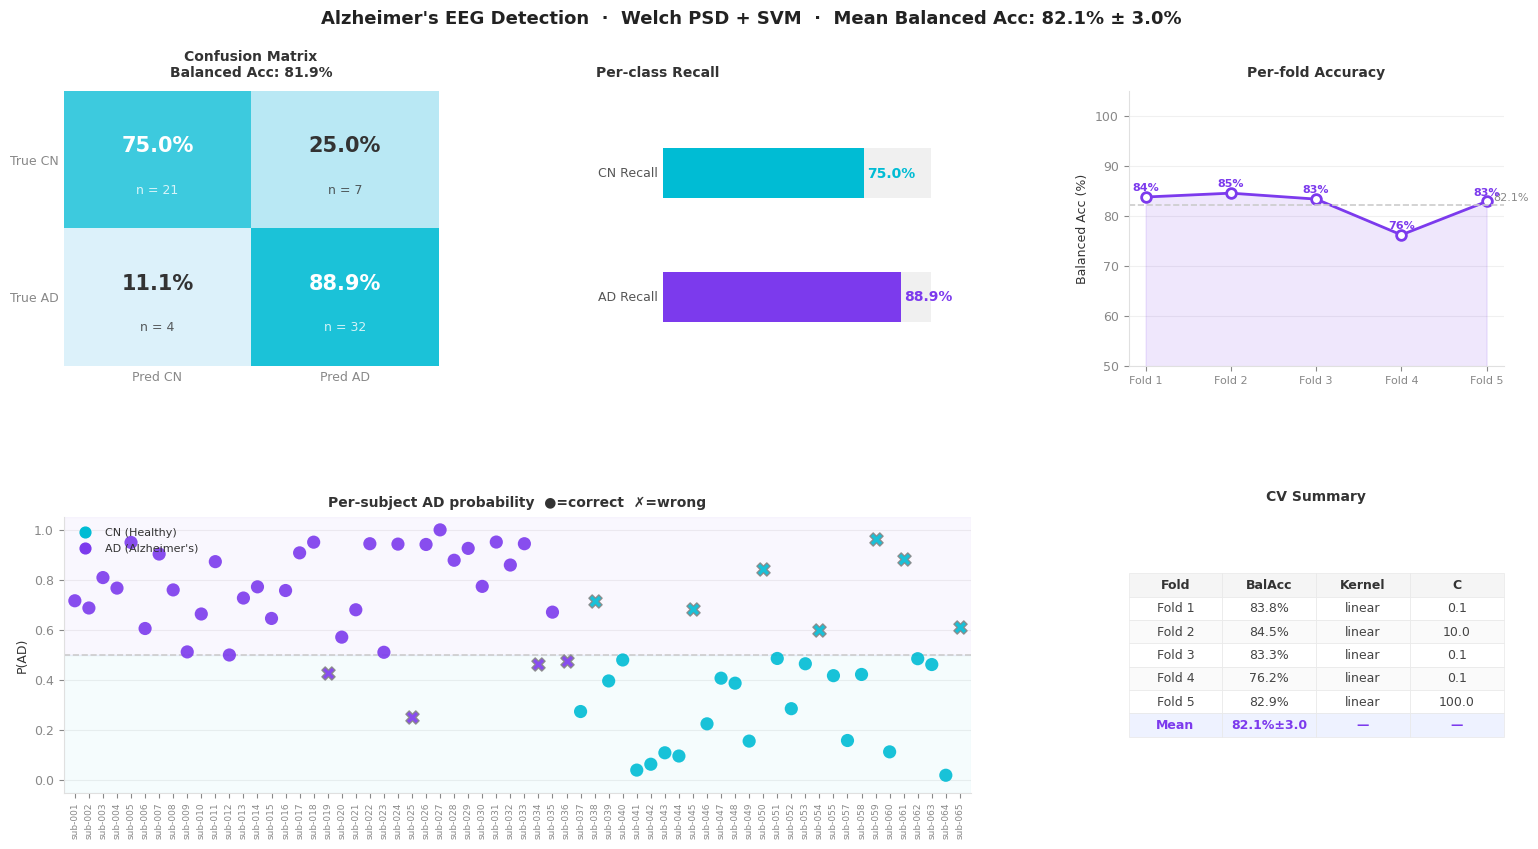

Saved → results_v12.png


In [ ]:
# Results Dashboard , Light Theme
# Style inspired by reference: white background, teal/purple palette,
# pill-shaped band labels, clean sans-serif typography.

all_true_arr = np.array(all_true)
all_pred_arr = np.array(all_pred)
mean_acc     = np.mean([r['bal_acc'] for r in fold_results])
std_acc      = np.std( [r['bal_acc'] for r in fold_results])
overall_bal  = balanced_accuracy_score(all_true_arr, all_pred_arr) * 100
cn_r  = recall_score(all_true_arr, all_pred_arr, pos_label=0) * 100
ad_r  = recall_score(all_true_arr, all_pred_arr, pos_label=1) * 100

fig = plt.figure(figsize=(16, 9), facecolor='white')
gs  = GridSpec(2, 3, figure=fig, hspace=0.55, wspace=0.42,
               left=0.07, right=0.97, top=0.88, bottom=0.1)

# Helper: pill-label
def pill(ax, x, y, text, color, fontsize=8, textcolor='white'):
    ax.text(x, y, f'  {text}  ', transform=ax.transData,
            fontsize=fontsize, fontweight='bold', color=textcolor,
            ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor=color,
                      edgecolor='none', alpha=0.9))


# 1. Confusion Matrix
ax_cm = fig.add_subplot(gs[0, 0])
cm      = confusion_matrix(all_true_arr, all_pred_arr)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

# White-to-color gradient per class
from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list('lc', ['#F8F8FF', CN_COLOR], N=256)
im = ax_cm.imshow(cm_norm, cmap=cmap, vmin=0, vmax=1, aspect='auto')

for i in range(2):
    for j in range(2):
        clr = 'white' if cm_norm[i,j] > 0.55 else '#333333'
        ax_cm.text(j, i-0.1, f'{cm_norm[i,j]*100:.1f}%',
                   ha='center', va='center', fontsize=15, fontweight='bold', color=clr)
        ax_cm.text(j, i+0.22, f'n = {cm[i,j]}',
                   ha='center', va='center', fontsize=9, color=clr, alpha=0.8)

ax_cm.set_xticks([0,1]); ax_cm.set_xticklabels(['Pred CN', 'Pred AD'], fontsize=9)
ax_cm.set_yticks([0,1]); ax_cm.set_yticklabels(['True CN', 'True AD'], fontsize=9)
ax_cm.set_title(f'Confusion Matrix\nBalanced Acc: {overall_bal:.1f}%',
                fontsize=10, fontweight='bold', color='#333333', pad=10)
ax_cm.spines[:].set_visible(False)
ax_cm.tick_params(length=0)


# 2. Per-class Recall bars (reference-style horizontal bars)
ax_bar = fig.add_subplot(gs[0, 1])

# Background track
for i, (label, val, col) in enumerate([('CN Recall', cn_r, CN_COLOR),
                                         ('AD Recall', ad_r, AD_COLOR)]):
    y_pos = 1 - i * 0.45
    # grey track
    ax_bar.barh(y_pos, 100, height=0.18, color='#F0F0F0',
                left=0, zorder=1)
    # filled bar
    ax_bar.barh(y_pos, val, height=0.18, color=col, left=0, zorder=2)
    # pill label
    ax_bar.text(-2, y_pos, label, ha='right', va='center',
                fontsize=9, color='#555555')
    ax_bar.text(val + 1, y_pos, f'{val:.1f}%',
                ha='left', va='center', fontsize=10,
                fontweight='bold', color=col)

ax_bar.set_xlim(-25, 115)
ax_bar.set_ylim(0.3, 1.3)
ax_bar.axis('off')
ax_bar.set_title('Per-class Recall', fontsize=10, fontweight='bold',
                 color='#333333', pad=10, loc='left')


# 3. Per-fold accuracy
ax_folds = fig.add_subplot(gs[0, 2])
fns  = [r['fold']    for r in fold_results]
bals = [r['bal_acc'] for r in fold_results]

# Thin line + filled area under
ax_folds.fill_between(fns, bals, alpha=0.12, color=AD_COLOR)
ax_folds.plot(fns, bals, color=AD_COLOR, lw=2, marker='o',
              markersize=7, markerfacecolor='white', markeredgewidth=2,
              markeredgecolor=AD_COLOR)
ax_folds.axhline(mean_acc, color='#CCCCCC', lw=1.2, ls='--')
ax_folds.text(N_FOLDS + 0.08, mean_acc + 0.5, f'{mean_acc:.1f}%',
              color='#888888', fontsize=8, va='bottom')
ax_folds.set_ylim(50, 105)
ax_folds.set_xticks(fns)
ax_folds.set_xticklabels([f'Fold {f}' for f in fns], fontsize=8)
ax_folds.set_ylabel('Balanced Acc (%)', fontsize=9)
ax_folds.set_title('Per-fold Accuracy', fontsize=10, fontweight='bold', color='#333333', pad=10)
ax_folds.yaxis.grid(True)
ax_folds.set_axisbelow(True)
for val, fold in zip(bals, fns):
    ax_folds.text(fold, val + 1.2, f'{val:.0f}%', ha='center',
                  fontsize=8, color=AD_COLOR, fontweight='bold')


# 4. Subject probability strip (reference scatter style)
ax_sc = fig.add_subplot(gs[1, :2])
subs    = sorted(all_prob.keys())
probs_s = [all_prob[s]['prob'] for s in subs]
trues_s = [all_prob[s]['true'] for s in subs]
votes_s = [all_prob[s]['vote'] for s in subs]
correct = [v == t for v, t in zip(votes_s, trues_s)]
scols   = [CN_COLOR if t == 0 else AD_COLOR for t in trues_s]
markers = ['o' if c else 'X' for c in correct]

# Background shading
ax_sc.axhspan(0.5, 1.05, alpha=0.04, color=AD_COLOR)
ax_sc.axhspan(-0.05, 0.5, alpha=0.04, color=CN_COLOR)
ax_sc.axhline(0.5, color='#CCCCCC', lw=1.2, ls='--', zorder=1)

for xi, (sub, p, col, mk, corr) in enumerate(zip(subs, probs_s, scols, markers, correct)):
    ax_sc.scatter(xi, p, c=col, marker=mk, s=90, zorder=3,
                  edgecolors='#888888' if not corr else 'none',
                  linewidths=1.0, alpha=0.9)

ax_sc.set_ylim(-0.05, 1.05)
ax_sc.set_xlim(-0.8, len(subs) - 0.2)
ax_sc.set_ylabel('P(AD)', fontsize=9)
ax_sc.set_title('Per-subject AD probability  ●=correct  ✗=wrong',
                fontsize=10, fontweight='bold', color='#333333', pad=8)
ax_sc.set_xticks(range(len(subs)))
ax_sc.set_xticklabels(subs, rotation=90, fontsize=6.5)
ax_sc.yaxis.grid(True); ax_sc.set_axisbelow(True)

# Legend pills
for label, col in [('CN (Healthy)', CN_COLOR), ("AD (Alzheimer's)", AD_COLOR)]:
  ax_sc.scatter([], [], c=col, s=60, label=label)
ax_sc.legend(fontsize=8, loc='upper left')


# 5. CV summary table
ax_t = fig.add_subplot(gs[1, 2])
ax_t.axis('off')

rows       = [[f'Fold {r["fold"]}', f'{r["bal_acc"]:.1f}%', r["kernel"], str(r["C"])]
              for r in fold_results]
rows.append(['Mean', f'{mean_acc:.1f}%±{std_acc:.1f}', '—', '—'])
col_labels = ['Fold', 'BalAcc', 'Kernel', 'C']
tbl = ax_t.table(cellText=rows, colLabels=col_labels,
                 loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(9)
tbl.scale(1, 1.4)

for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor('#E8E8E8')
    cell.set_linewidth(0.5)
    if r == 0:
        cell.set_facecolor('#F5F5F5')
        cell.set_text_props(color='#333333', fontweight='bold')
    elif r == len(rows):
        cell.set_facecolor('#EEF2FF')
        cell.set_text_props(color=AD_COLOR, fontweight='bold')
    else:
        cell.set_facecolor('white' if r % 2 == 1 else '#FAFAFA')
        cell.set_text_props(color='#444444')
ax_t.set_title('CV Summary', fontsize=10, fontweight='bold', color='#333333', pad=12)

# Suptitle
fig.suptitle(f"Alzheimer's EEG Detection  ·  Welch PSD + SVM  ·  Mean Balanced Acc: {mean_acc:.1f}% ± {std_acc:.1f}%",fontsize=13, fontweight='bold', color='#222222', y=0.97)

plt.savefig('results_v12.png', dpi=160, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved → results_v12.png')

## Step 4: Feature Importance

Band-power visualization comparing the AD and cognitively normal (CN)
groups: horizontal bars summarizing relative power per frequency band,
an illustrative waveform per band, and a channel-level power summary.


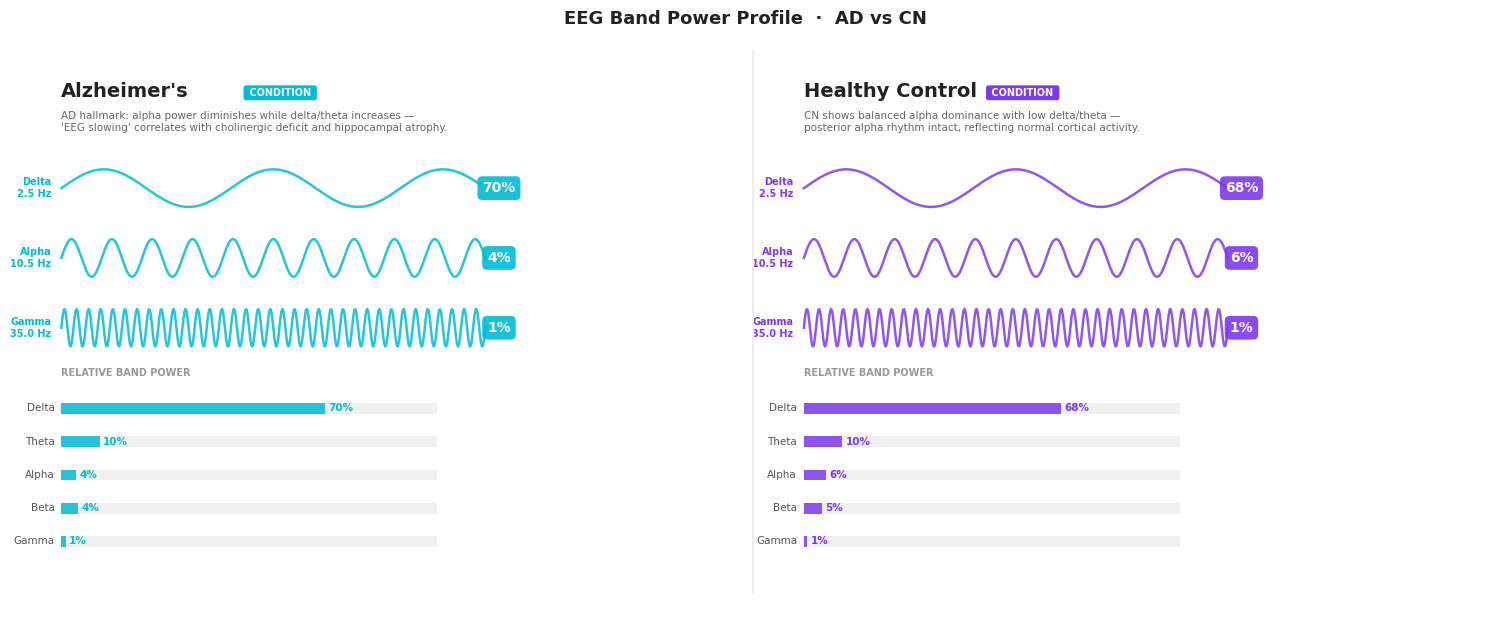

Saved → band_profile_v12.png


In [ ]:
# Feature Importance
# Train linear SVM on all subjects for interpretable weights.

scaler_all = StandardScaler()
X_s        = scaler_all.fit_transform(X)
pca_all    = PCA(n_components=0.95, whiten=True, random_state=42)
X_pca      = pca_all.fit_transform(X_s)
svm_all    = SVC(kernel='linear', C=1.0, probability=True,
                 class_weight='balanced', random_state=42)
svm_all.fit(X_pca, y)

# Compute mean band power across all subjects (separate AD/CN)

# Re-extract band powers for plotting (from raw X features)
# Band power block starts at index 2*19*F_dim (after log_psd + rel_psd)
# Simpler: re-run welch on the first few subjects per group and average

def mean_band_power_by_group(indices):
    """Returns dict band->mean_relative_power across subjects in indices."""
    totals = {b: [] for b in BANDS}
    for i in indices:
        raw = raws[np.where(subject_ids == ids[i])[0][0]]
        raw2 = raw.copy()
        raw2.filter(FREQ_LO, FREQ_HI, method='fir', verbose=False)
        raw2.notch_filter(50.0, verbose=False)
        d = raw2.get_data()[:N_CHANNELS]
        W = int(6.0 * SFREQ)
        wins = [d[:, s:s+W] for s in range(0, d.shape[1]-W+1, int(W*0.5))]
        if not wins: continue
        wins = np.array(wins)
        # mean PSD
        psds = []
        for win in wins[:10]:   # max 10 windows per subject for speed
            ch_psds = []
            for ch in range(N_CHANNELS):
                f, pxx = welch(win[ch], fs=SFREQ, nperseg=NPERSEG, noverlap=NPERSEG//2)
                ch_psds.append(pxx)
            psds.append(ch_psds)
        psds = np.array(psds).mean(0)  # (19, F)
        total = psds.sum() + 1e-30
        for b, (lo, hi) in BANDS.items():
            m = (f >= lo) & (f < hi)
            totals[b].append(psds[:, m].sum() / total)
    return {b: np.mean(v) for b, v in totals.items() if v}

ad_idx = np.where(y == 1)[0]
cn_idx = np.where(y == 0)[0]
ad_bp  = mean_band_power_by_group(ad_idx)
cn_bp  = mean_band_power_by_group(cn_idx)


# Plot
fig, axes = plt.subplots(1, 2, figsize=(15, 6), facecolor='white')
fig.suptitle("EEG Band Power Profile  ·  AD vs CN",
             fontsize=13, fontweight='bold', color='#222222', y=1.02)

def draw_eeg_panel(ax, title, subtitle, band_vals, color, tag_col):
    ax.set_facecolor('white')
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.axis('off')

    # Title area
    ax.text(0.1, 9.5, title, fontsize=14, fontweight='bold', color='#222222',
            transform=ax.transData)
    # Condition pill
    ax.text(2.8, 9.52, ' CONDITION ', fontsize=7, fontweight='bold',
            color='white', transform=ax.transData,
            bbox=dict(boxstyle='round,pad=0.25', facecolor=color, edgecolor='none'))
    ax.text(0.1, 8.9, subtitle, fontsize=7.5, color='#666666',
            transform=ax.transData, wrap=True)

    # Sine wave illustrations per band
    band_items = list(BANDS.items())
    wave_y_positions = [7.8, 6.5, 5.2]
    wave_freqs       = [band_items[0], band_items[2], band_items[4]]  # delta, alpha, gamma

    t = np.linspace(0, 10, 500)
    for idx, (band_name, (lo, hi)) in enumerate(wave_freqs):
        y_center  = wave_y_positions[idx]
        freq_mid  = (lo + hi) / 2
        amplitude = 0.35
        wave      = amplitude * np.sin(2 * np.pi * freq_mid * t / 10)
        ax.plot(t * 0.62 + 0.1, wave + y_center, color=color, lw=1.8, alpha=0.85)

        # Frequency label pill
        ax.text(-0.05, y_center, f'{band_name.capitalize()}\n{freq_mid:.1f} Hz',
                fontsize=7, color=color, fontweight='bold', ha='right', va='center',
                transform=ax.transData)

        # Percentage badge
        pct = band_vals.get(band_name, 0) * 100
        ax.text(6.5, y_center, f'{pct:.0f}%',
                fontsize=10, fontweight='bold', color='white', ha='center', va='center',
                transform=ax.transData,
                bbox=dict(boxstyle='round,pad=0.35', facecolor=color,
                          edgecolor='none', alpha=0.9))

    # Horizontal band-power bars
    ax.text(0.1, 4.3, 'RELATIVE BAND POWER', fontsize=7, color='#999999',
            fontweight='bold', transform=ax.transData)

    for row_i, (band_name, (lo, hi)) in enumerate(band_items):
        y_b   = 3.7 - row_i * 0.62
        pct   = band_vals.get(band_name, 0) * 100
        bar_w = pct / 100 * 5.5

        # Track
        track = plt.Rectangle((0.1, y_b - 0.1), 5.5, 0.2,
                               facecolor='#F0F0F0', edgecolor='none',
                               transform=ax.transData)
        ax.add_patch(track)
        # Filled
        filled = plt.Rectangle((0.1, y_b - 0.1), bar_w, 0.2,
                                facecolor=color, edgecolor='none', alpha=0.85,
                                transform=ax.transData)
        ax.add_patch(filled)

        ax.text(0.0, y_b, band_name.capitalize(), fontsize=7.5,
                color='#555555', ha='right', va='center', transform=ax.transData)
        ax.text(0.1 + bar_w + 0.05, y_b, f'{pct:.0f}%',
                fontsize=7.5, color=color, fontweight='bold',
                ha='left', va='center', transform=ax.transData)

# AD panel
draw_eeg_panel(
    axes[0],
    title="Alzheimer's",
    subtitle="AD hallmark: alpha power diminishes while delta/theta increases —\n"
             "'EEG slowing' correlates with cholinergic deficit and hippocampal atrophy.",
    band_vals=ad_bp,
    color=CN_COLOR,
    tag_col=CN_COLOR,
)

# CN panel
draw_eeg_panel(
    axes[1],
    title="Healthy Control",
    subtitle="CN shows balanced alpha dominance with low delta/theta —\n"
             "posterior alpha rhythm intact, reflecting normal cortical activity.",
    band_vals=cn_bp,
    color=AD_COLOR,
    tag_col=AD_COLOR,
)

# Divider line between panels
fig.add_artist(plt.Line2D([0.505, 0.505], [0.05, 0.95],
               transform=fig.transFigure, color='#EEEEEE', lw=1.5))

plt.tight_layout()
plt.savefig('band_profile_v12.png', dpi=160, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved → band_profile_v12.png')